In [6]:
import os

DOSSIER_SEG = os.path.join(RACINE, "data", "segmentees")

print("Illustrations segmentées par source :\n")

total = 0
for dossier in sorted(os.listdir(DOSSIER_SEG)):
    chemin = os.path.join(DOSSIER_SEG, dossier)
    if not os.path.isdir(chemin) or "_flip" in dossier:
        continue
    if dossier == "cuivre_pdfs":
        for edition in sorted(os.listdir(chemin)):
            sous = os.path.join(chemin, edition)
            if os.path.isdir(sous) and "_flip" not in edition:
                n = len([f for f in os.listdir(sous) if f.endswith(".jpg")])
                print(f"  {edition:50s} : {n}")
                total += n
    else:
        n = len([f for f in os.listdir(chemin) if f.endswith(".jpg")])
        print(f"  {dossier:50s} : {n}")
        total += n

print(f"\n  {'TOTAL':50s} : {total}")

Illustrations segmentées par source :

  bois_salomon_lyon1557                              : 164
  bois_solis_francfort1581                           : 187
  bois_wickram_mayence1545                           : 52
  cuivre_clein_paris1637                             : 18
  cuivre_passe_metamorphoseon                        : 135
  cuivre_passe_nasonis                               : 136
  cuivre_renouard_traduites                          : 16
  cuivre_renouard_traduittes                         : 17

  TOTAL                                              : 725


In [ ]:
Bois (taille-douce non confirmée) :

Salomon, Bernard                   164
Wickram, Jörg                      52
Eskrich, Pierre                
Leroy II, Guillaume
Solis, Virgil                      187

Taille douce :

Savery, Salomon (clein)            18
Passe, Crispin de                  271
Gaultier, Léonard
Isaac, Jaspar
Briot, Isaac
Baur, Johann Wilhelm
Altzenbach, Gerhardt
Goltzius, Hendrick
Mulder, Joseph
Weyen, Laurent
Blanchin, Jean
Philippe, Pierre

In [12]:
import requests

BASE_URL = "https://gallica-search-api-preprod.bnf.lajavaness.com"

sources_gaultier = {
    "bsb11913284"  : ("bsb", "gaultier_guillemot1610"),
    "bpt6k6277348n": ("bnf", "gaultier_veuveguillemot1614"),
    "bsb10242228"  : ("bsb", "gaultier_1616"),
}

for ark, (source, nom) in sources_gaultier.items():
    if source == "bsb":
        r = requests.get(
            f"https://api.digitale-sammlungen.de/iiif/presentation/v2/{ark}/manifest",
            timeout=15
        )
        if r.status_code == 200:
            pages = len(r.json()["sequences"][0]["canvases"])
            print(f"✓ BSB {ark} — {nom} : {pages} pages")
        else:
            print(f"✗ BSB {ark} — {nom} : HTTP {r.status_code}")
    else:
        r = requests.get(
            f"{BASE_URL}/api/ouvrages/{ark}/illustrations",
            timeout=15
        )
        data = r.json()
        if isinstance(data, list):
            print(f"✓ API {ark} — {nom} : {len(data)} illustrations")
        else:
            print(f"✗ API {ark} — {nom} : {data.get('message', '')}")

✓ BSB bsb11913284 — gaultier_guillemot1610 : 846 pages
✗ API bpt6k6277348n — gaultier_veuveguillemot1614 : Ouvrage bpt6k6277348n not found.
✓ BSB bsb10242228 — gaultier_1616 : 1242 pages


In [17]:
r = requests.get(
    "https://babel.hathitrust.org/cgi/pt?id=hvd.hn64uf&seq=20",
    timeout=15
)
print(f"HathiTrust : HTTP {r.status_code}")

HathiTrust : HTTP 403


In [18]:
r = requests.get(
    "https://gallica.bnf.fr/services/engine/search/sru?operation=searchRetrieve&query=dc.title+all+%22metamorphoses+corneille%22+and+dc.date+all+%221669%22",
    timeout=15
)
print(r.text[:500])

Access Denied: 403 Access Interdit


In [20]:
RENOMMAGES_DEPASSE = {
    "cuivre_depasse_metamorphoseon" : "cuivre_depasse_koln1602",
    "cuivre_depasse_nasonis"        : "cuivre_depasse_arnhem1607",
}

for ancien, nouveau in RENOMMAGES_DEPASSE.items():
    src = os.path.join(DOSSIER_SEG, "cuivre_pdfs", ancien)
    dst = os.path.join(DOSSIER_SEG, "cuivre_pdfs", nouveau)
    if os.path.exists(src):
        os.rename(src, dst)
        print(f"✓ {ancien} → {nouveau}")
    src_flip = os.path.join(DOSSIER_SEG, "cuivre_pdfs", f"{ancien}_flip")
    dst_flip = os.path.join(DOSSIER_SEG, "cuivre_pdfs", f"{nouveau}_flip")
    if os.path.exists(src_flip):
        os.rename(src_flip, dst_flip)
        print(f"✓ {ancien}_flip → {nouveau}_flip")

In [1]:
import requests
from PIL import Image
from io import BytesIO

# Test sur la page Blanchin
urls_test = [
    "http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=34",
    "http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=64",
]

for url in urls_test:
    r = requests.get(url, timeout=15)
    print(f"HTTP {r.status_code} — {url}")
    print(f"  Content-Type : {r.headers.get('Content-Type', '')}")
    print(f"  Taille       : {len(r.content)} bytes")
    print()

HTTP 200 — http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=34
  Content-Type : text/html
  Taille       : 13985 bytes

HTTP 200 — http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=64
  Content-Type : text/html
  Taille       : 8761 bytes



In [2]:
from bs4 import BeautifulSoup

for url, graveur in [
    ("http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=34", "Blanchin"),
    ("http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=64", "Weyen"),
]:
    r    = requests.get(url, timeout=15)
    soup = BeautifulSoup(r.text, "html.parser")
    imgs = soup.find_all("img")
    print(f"\n── {graveur} — {len(imgs)} images trouvées ──")
    for img in imgs[:10]:
        print(f"  {img.get('src', '')}")


── Blanchin — 30 images trouvées ──
  ../images/icoBDOblanco.png
  ../images/icoBibliotecasLen.png
  ../images/icoEdicionesLen.png
  ../images/icoEtiquetasLen.png
  ../images/icoLineaTemporalLen.png
  ../images/icoBuscarLen.png
  ../images/icoProyectoLen.png
  ../images/icoMOvidiusPictusL.fw.png
  ../images/images/M.BpC.Rou.1676/M.BpC.Rou.1676.a.jpg
  ../images/images/M.BpC.Rou.1676/M.BpC.Rou.1676.f.jpg

── Weyen — 18 images trouvées ──
  ../images/icoBDOblanco.png
  ../images/icoBibliotecasLen.png
  ../images/icoEdicionesLen.png
  ../images/icoEtiquetasLen.png
  ../images/icoLineaTemporalLen.png
  ../images/icoBuscarLen.png
  ../images/icoProyectoLen.png
  ../images/icoMOvidiusPictusL.fw.png
  ../images/images/M.BpC.Par.1669/M.BpC.Par.1669.a.jpg
  ../images/images/M.BpC.Par.1669/M.BpC.Par.1669.1.1.jpg


HTTP 200 — 114226 bytes


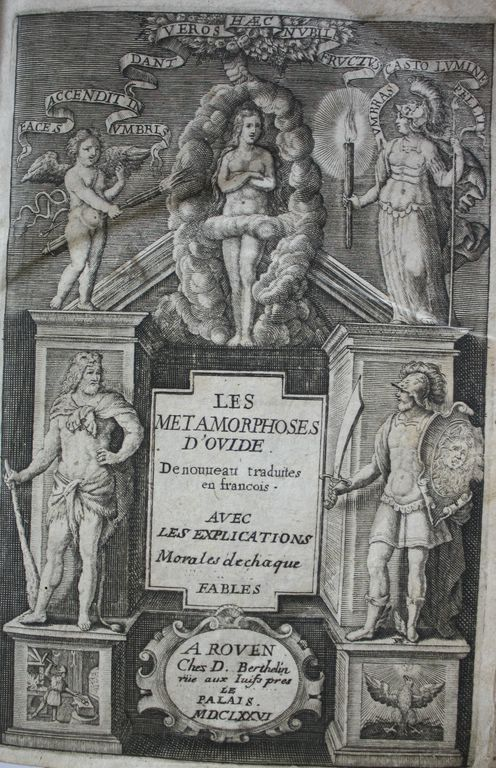

  Taille image : (496, 768)


In [3]:
BASE_OVIDIUS = "http://www.ovidiuspictus.es"

# Tester le téléchargement d'une image
url_test = f"{BASE_OVIDIUS}/images/images/M.BpC.Rou.1676/M.BpC.Rou.1676.a.jpg"
r = requests.get(url_test, timeout=15)
print(f"HTTP {r.status_code} — {len(r.content)} bytes")

if r.status_code == 200:
    img = Image.open(BytesIO(r.content))
    img.show()
    print(f"  Taille image : {img.size}")

In [4]:
urls_leroy = [
    ("http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=146", "leroy_huguetan1516"),
    ("http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=108", "leroy_mareschal1519"),
    ("http://www.ovidiuspictus.es/en/ilustracionesejemplar.php?clave=106", "leroy_crespin1527"),
]

for url, nom in urls_leroy:
    r    = requests.get(url, timeout=15)
    soup = BeautifulSoup(r.text, "html.parser")
    imgs = [img.get("src", "") for img in soup.find_all("img")
            if "/images/images/" in img.get("src", "")]
    print(f"{nom} : {len(imgs)} illustrations — HTTP {r.status_code}")

leroy_huguetan1516 : 17 illustrations — HTTP 200
leroy_mareschal1519 : 16 illustrations — HTTP 200
leroy_crespin1527 : 16 illustrations — HTTP 200


In [5]:
r    = requests.get("http://www.ovidiuspictus.es/en/listadoejemplares.php?de=edicion&clave=108", timeout=15)
soup = BeautifulSoup(r.text, "html.parser")

print("Tous les liens de la page :\n")
for a in soup.find_all("a", href=True):
    print(f"  {a['href']}")

Tous les liens de la page :

  bdo.php
  bibliotecas.php
  listadoediciones.php
  etiquetas.php
  lineatemporal.php
  busqueda.php
  proyecto.php
  ../index.php
  #
  #
  ../visualizacionejemplar.php?clave=112
  ../visualizacionejemplar.php?clave=112
  ../visualizacionejemplar.php?clave=192
  ../visualizacionejemplar.php?clave=192
  copyright.php 
  mailto:ovidiuspictus@gmail.com
  https://www.facebook.com/ovidiuspictus/
  https://twitter.com/ovidiuspictus


In [6]:
r    = requests.get("http://www.ovidiuspictus.es/en/visualizacionejemplar.php?clave=112", timeout=15)
soup = BeautifulSoup(r.text, "html.parser")

print("Tous les liens de la page :\n")
for a in soup.find_all("a", href=True):
    print(f"  {a['href']}")

Tous les liens de la page :

  bdo.php
  bibliotecas.php
  listadoediciones.php
  etiquetas.php
  lineatemporal.php
  busqueda.php
  proyecto.php
  ../index.php
  #
  #
  ../listadoejemplares.php?de='biblioteca'&clave=24
  ../ilustracionesejemplar.php?clave=112
  
  #
  #
  ../http
  #
  #
  #
  #
  
  ../ilustracionesejemplar.php?clave=112
  copyright.php 
  mailto:ovidiuspictus@gmail.com
  https://www.facebook.com/ovidiuspictus/
  https://twitter.com/ovidiuspictus


In [7]:
r    = requests.get("http://www.ovidiuspictus.es/en/listadoejemplares.php?de=edicion&clave=108", timeout=15)
soup = BeautifulSoup(r.text, "html.parser")

for a in soup.find_all("a", href=True):
    if "visualizacionejemplar" in a["href"]:
        print(a["href"])

../visualizacionejemplar.php?clave=112
../visualizacionejemplar.php?clave=112
../visualizacionejemplar.php?clave=192
../visualizacionejemplar.php?clave=192


Dossiers actuels dans data/segmentees/ :



NameError: name 'DOSSIER_SEG' is not defined

In [11]:
for bsb_id, label in [
    ("bsb10872075", "Baur — Augsbourg 1709"),
    ("bsb10872073", "Baur — Vienne 1639"),
]:
    r = requests.get(
        f"https://api.digitale-sammlungen.de/iiif/presentation/v2/{bsb_id}/manifest",
        timeout=15
    )
    if r.status_code == 200:
        pages = len(r.json()["sequences"][0]["canvases"])
        print(f"✓ {label} : {pages} pages")
    else:
        print(f"✗ {label} : HTTP {r.status_code}")

✓ Baur — Augsbourg 1709 : 458 pages
✓ Baur — Vienne 1639 : 246 pages


In [12]:
for source, label in [
    ("bnf", "btv1b54000051z", "Tempesta — De Jode, Anvers 1606"),
    ("bsb", "bsb00008186",    "Tempesta — Jansonius, Amsterdam 1610"),
]:
    if source == "bnf":
        r = requests.get(f"{BASE_URL}/api/ouvrages/btv1b54000051z/illustrations", timeout=15)
        data = r.json()
        if isinstance(data, list):
            print(f"✓ {label} : {len(data)} illustrations — API BnF")
        else:
            r2 = requests.get("https://gallica.bnf.fr/iiif/ark:/12148/btv1b54000051z/manifest.json", timeout=15)
            print(f"  API : {data.get('message','')} | IIIF : HTTP {r2.status_code}")
    else:
        r = requests.get(f"https://api.digitale-sammlungen.de/iiif/presentation/v2/bsb00008186/manifest", timeout=15)
        if r.status_code == 200:
            pages = len(r.json()["sequences"][0]["canvases"])
            print(f"✓ {label} : {pages} pages — BSB")
        else:
            print(f"✗ {label} : HTTP {r.status_code}")

ValueError: too many values to unpack (expected 2)

In [14]:
import requests

BASE_URL = "https://gallica-search-api-preprod.bnf.lajavaness.com"

for source, ark, label in [
    ("bnf", "btv1b54000051z", "Tempesta — De Jode, Anvers 1606"),
    ("bsb", "bsb00008186",    "Tempesta — Jansonius, Amsterdam 1610"),
]:
    if source == "bnf":
        r = requests.get(f"{BASE_URL}/api/ouvrages/{ark}/illustrations", timeout=15)
        data = r.json()
        if isinstance(data, list):
            print(f"✓ {label} : {len(data)} illustrations — API BnF")
        else:
            r2 = requests.get(f"https://gallica.bnf.fr/iiif/ark:/12148/{ark}/manifest.json", timeout=15)
            print(f"  API : {data.get('message','')} | IIIF : HTTP {r2.status_code}")
    else:
        r = requests.get(f"https://api.digitale-sammlungen.de/iiif/presentation/v2/{ark}/manifest", timeout=15)
        if r.status_code == 200:
            pages = len(r.json()["sequences"][0]["canvases"])
            print(f"✓ {label} : {pages} pages — BSB")
        else:
            print(f"✗ {label} : HTTP {r.status_code}")

✓ Tempesta — De Jode, Anvers 1606 : 153 illustrations — API BnF
✓ Tempesta — Jansonius, Amsterdam 1610 : 306 pages — BSB


In [2]:
import requests 
r = requests.get(
    "https://api.digitale-sammlungen.de/iiif/presentation/v2/bsb00004340/manifest",
    timeout=15
)
if r.status_code == 200:
    pages = len(r.json()["sequences"][0]["canvases"])
    print(f"✓ Van der Borcht — Plantin, Anvers 1591 : {pages} pages")
else:
    print(f"✗ HTTP {r.status_code}")

✓ Van der Borcht — Plantin, Anvers 1591 : 386 pages


In [4]:
import requests

BASE_URL = "https://gallica-search-api-preprod.bnf.lajavaness.com"
for ark, label in [
    ("bpt6k15151988", "Bouché — Blaeu Amsterdam 1702 ex1"),
    ("bpt6k722086",   "Bouché — Blaeu Amsterdam 1702 ex2"),
]:
    r = requests.get(f"{BASE_URL}/api/ouvrages/{ark}/illustrations", timeout=15)
    data = r.json()
    if isinstance(data, list):
        print(f"✓ {label} : {len(data)} illustrations — API BnF")
    else:
        r2 = requests.get(f"https://gallica.bnf.fr/iiif/ark:/12148/{ark}/manifest.json", timeout=15)
        print(f"✗ {label} — API : {data.get('message','')} | IIIF : HTTP {r2.status_code}")

✓ Bouché — Blaeu Amsterdam 1702 ex1 : 0 illustrations — API BnF
✗ Bouché — Blaeu Amsterdam 1702 ex2 — API : Ouvrage bpt6k722086 not found. | IIIF : HTTP 403


In [5]:
r = requests.get(
    "https://gallica.bnf.fr/iiif/ark:/12148/bpt6k15151988/manifest.json",
    timeout=15
)
print(f"IIIF : HTTP {r.status_code}")
if r.status_code == 200:
    pages = len(r.json()["sequences"][0]["canvases"])
    print(f"  {pages} pages")

IIIF : HTTP 403


In [6]:
import os

RACINE = os.path.abspath("../../../")

def tree(chemin, niveau=0, max_niveau=2):
    if niveau > max_niveau:
        return
    try:
        for item in sorted(os.listdir(chemin)):
            if item.startswith(".") or item == "__pycache__":
                continue
            chemin_item = os.path.join(chemin, item)
            print("  " * niveau + f"├── {item}")
            if os.path.isdir(chemin_item):
                tree(chemin_item, niveau + 1, max_niveau)
    except PermissionError:
        pass

tree(RACINE)

├── data
  ├── annotations
  ├── cuivre_pdfs_bruts
    ├── cuivre_bouche_blaeu_amsterdam1702.pdf
    ├── cuivre_briot_drobet_lyon1628.pdf
    ├── cuivre_depasse_depasse_koln1602.pdf
    ├── cuivre_depasse_jansonius_arnhem1607.pdf
    ├── cuivre_gaultier_veuveguillemot_paris1614.pdf
    ├── cuivre_goltzius_goltzius_haarlem1589.pdf
    ├── cuivre_isaac_langelier_paris1617.pdf
    ├── cuivre_monconet_sommaville_paris1660.pdf
  ├── datasets
    ├── bois_cuivre
    ├── graveur
    ├── themes_iconographiques
  ├── manifests
  ├── segmentees
    ├── bois_eskrich_rouille_lyon1556
    ├── bois_leroy_gueynard_lyon1510
    ├── bois_salomon_rouille_lyon1557
    ├── bois_salomon_rouille_lyon1557_flip
    ├── bois_solis_feyerabend_francfort1581
    ├── bois_solis_feyerabend_francfort1581_flip
    ├── bois_wickram_behem_mayence1545
    ├── bois_wickram_behem_mayence1545_flip
    ├── cuivre_baur_sn_augsbourg1709
    ├── cuivre_baur_sn_vienne1639
    ├── cuivre_blanchin_berthelin_rouen1651
    ├── cuiv